In [2]:
import sys
import os
sys.path.append('/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats 
from scipy.stats import shapiro , kstest, mannwhitneyu, ttest_rel
import torch
from torch import nn
from datasets.datasets import MRIDataset, STAREDataset
import random

from helper_func.analyis_helper import clean_df, plot_boxplots, visualize, generate_batch_views, visualize_views, visualize_brats

## BraTS Visualization

[[ 47. 109.  68. 128.]]
class 0: any=True, in frame 92=True
class 1: any=True, in frame 92=True
class 2: any=True, in frame 92=True
class 3: any=True, in frame 92=True


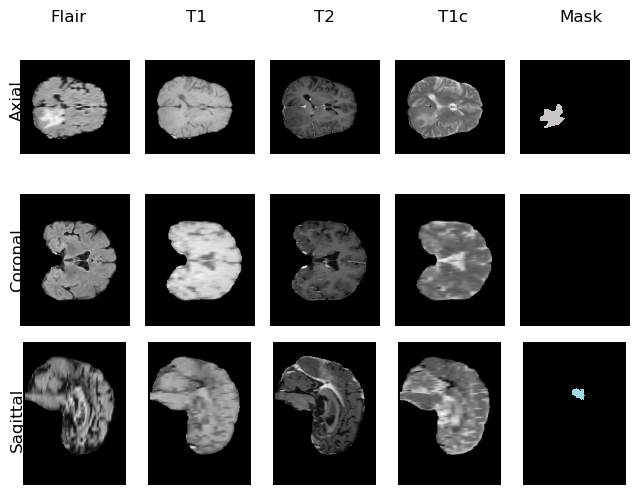

[[0. 0. 0. 0.]]
class 0: any=True, in frame 131=True
class 1: any=False, in frame 131=False
class 2: any=True, in frame 131=True
class 3: any=True, in frame 131=True


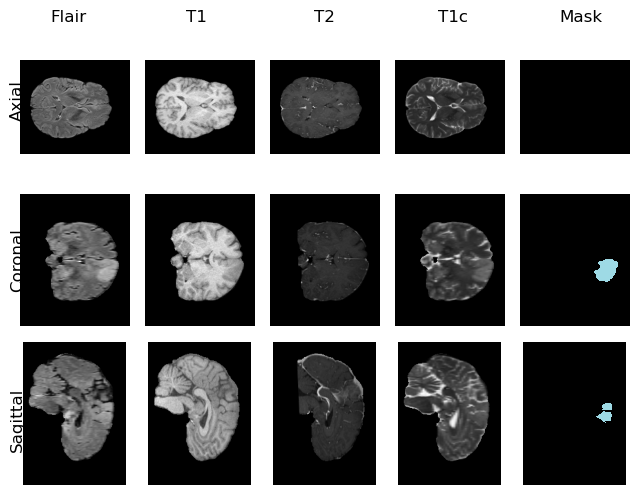

[[ 91. 121. 144. 164.]]
class 0: any=True, in frame 68=True
class 1: any=True, in frame 68=True
class 2: any=True, in frame 68=True
class 3: any=True, in frame 68=True


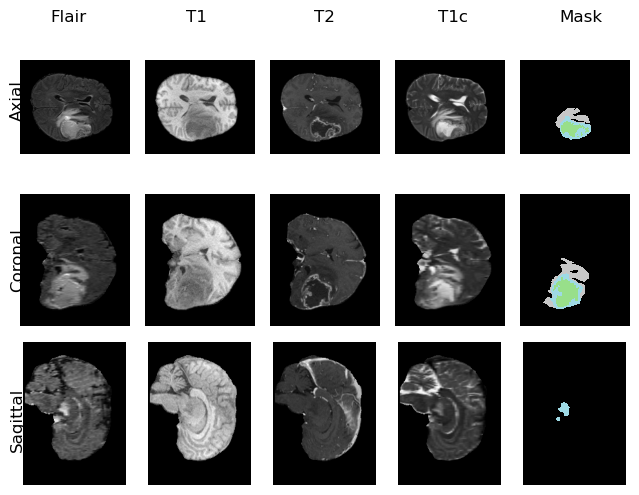

[[100.  39. 108.  44.]]
class 0: any=True, in frame 58=True
class 1: any=True, in frame 58=True
class 2: any=True, in frame 58=True
class 3: any=True, in frame 58=True


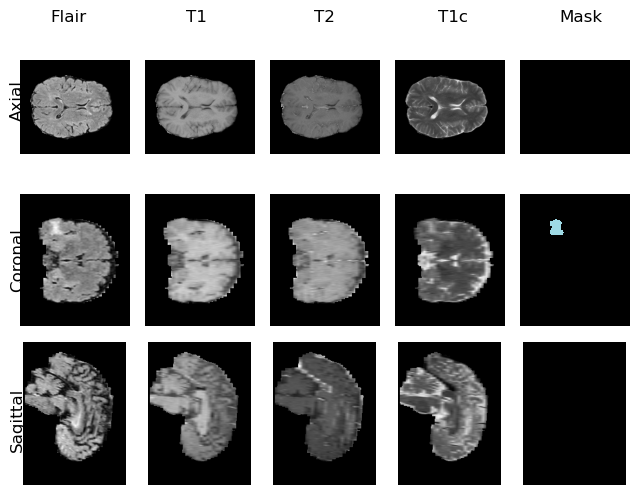

[[ 63. 103. 124. 153.]]
class 0: any=True, in frame 81=True
class 1: any=True, in frame 81=True
class 2: any=True, in frame 81=True
class 3: any=True, in frame 81=True


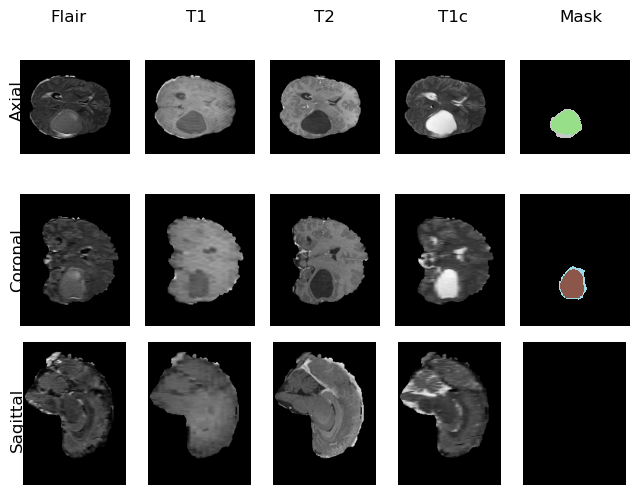

[[134.  74. 182.  98.]]
class 0: any=True, in frame 80=True
class 1: any=True, in frame 80=True
class 2: any=True, in frame 80=True
class 3: any=True, in frame 80=True


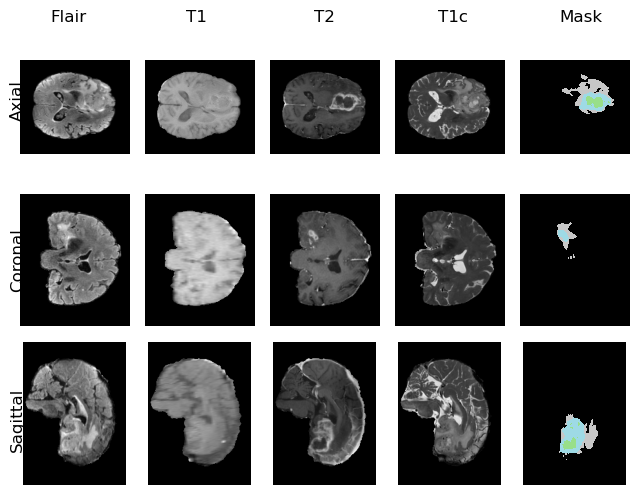

[[152.  90. 155.  93.]]
class 0: any=True, in frame 66=True
class 1: any=True, in frame 66=True
class 2: any=True, in frame 66=True
class 3: any=True, in frame 66=True


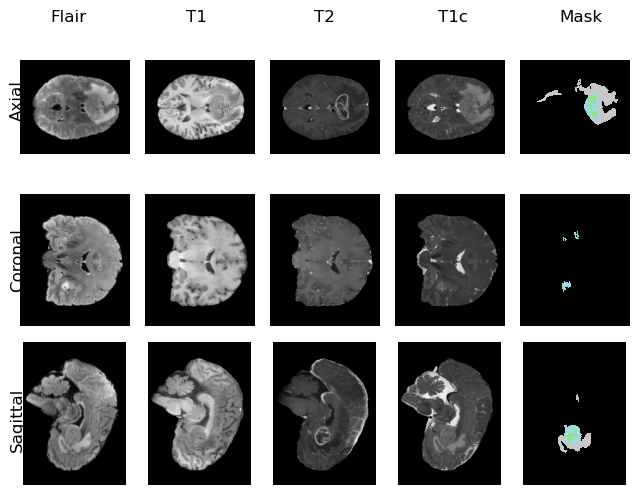

[[106.  58. 127.  73.]]
class 0: any=True, in frame 44=True
class 1: any=True, in frame 44=True
class 2: any=True, in frame 44=True
class 3: any=True, in frame 44=True


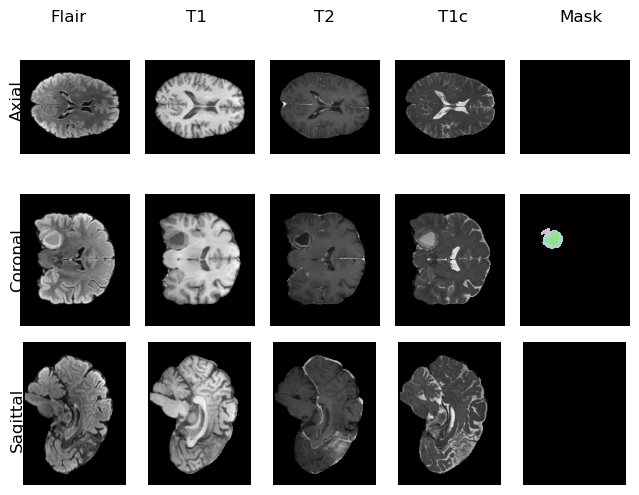

[[0. 0. 0. 0.]]
class 0: any=True, in frame 56=True
class 1: any=False, in frame 56=False
class 2: any=True, in frame 56=True
class 3: any=True, in frame 56=True


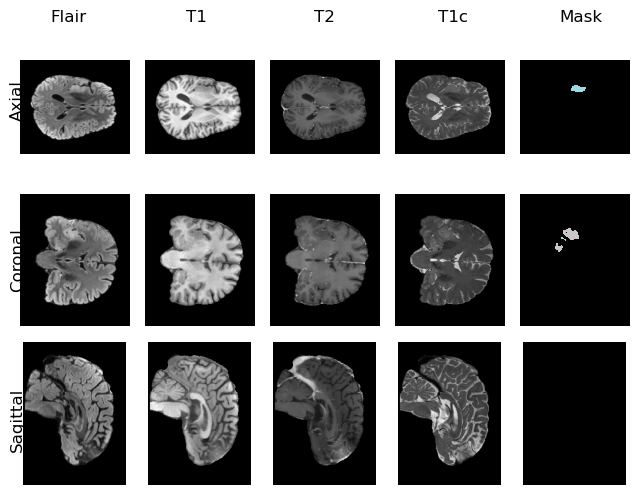

[[117. 110. 143. 143.]]
class 0: any=True, in frame 107=True
class 1: any=True, in frame 107=True
class 2: any=True, in frame 107=True
class 3: any=True, in frame 107=True


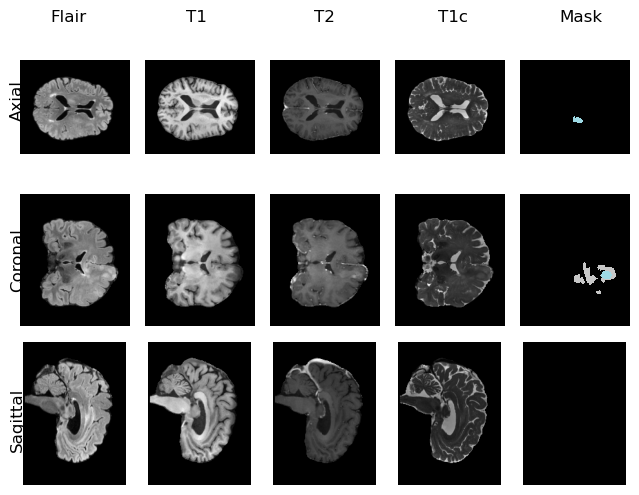

[[50. 48. 78. 73.]]
class 0: any=True, in frame 85=True
class 1: any=True, in frame 85=True
class 2: any=True, in frame 85=True
class 3: any=True, in frame 85=True


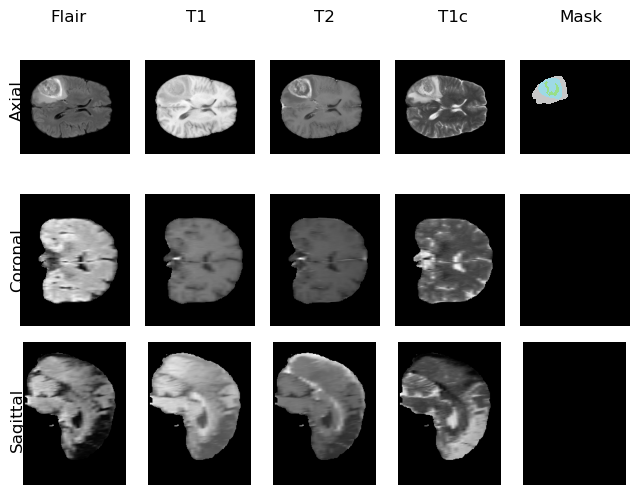

[[120.  81. 137.  89.]]
class 0: any=True, in frame 105=True
class 1: any=True, in frame 105=True
class 2: any=True, in frame 105=True
class 3: any=True, in frame 105=True


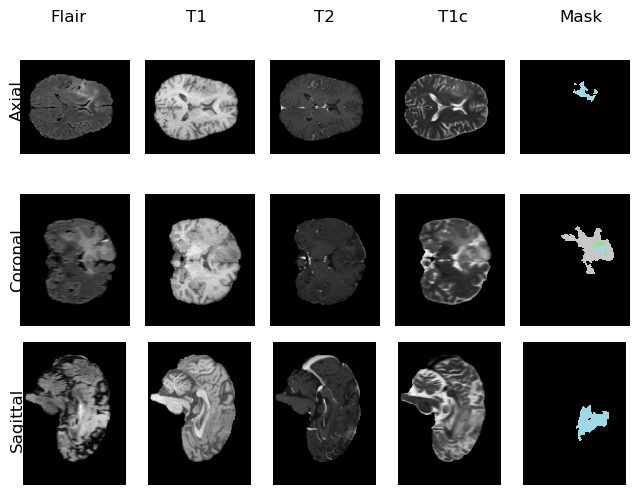

[[ 63.  60. 126. 110.]]
class 0: any=True, in frame 92=True
class 1: any=True, in frame 92=True
class 2: any=True, in frame 92=True
class 3: any=True, in frame 92=True


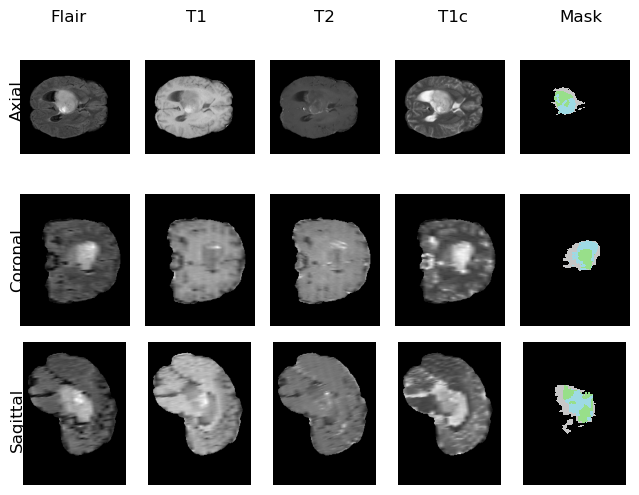

[[69. 36. 90. 70.]]
class 0: any=True, in frame 74=True
class 1: any=True, in frame 74=True
class 2: any=True, in frame 74=True
class 3: any=True, in frame 74=True


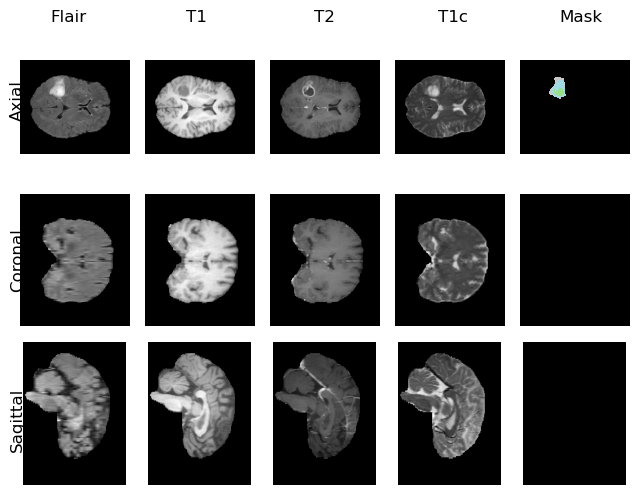

[[111. 122. 133. 145.]]
class 0: any=True, in frame 86=True
class 1: any=True, in frame 86=True
class 2: any=True, in frame 86=True
class 3: any=True, in frame 86=True


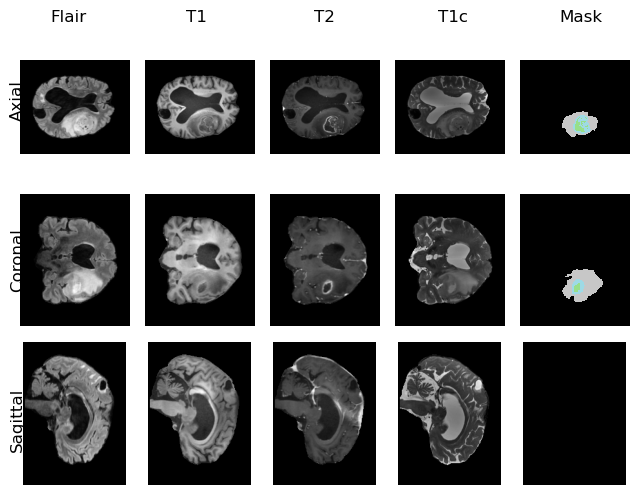

In [5]:
Brats_image_path = '/scratch-second/radjoe_data/BraTS/Training/images_UNN'
Brats_label_path = '/scratch-second/radjoe_data/BraTS/Training/labels_UNN'
GLI_FT_rows = random.sample(os.listdir(Brats_image_path), 15)
GLI_FT_dataset = MRIDataset(Brats_image_path, Brats_label_path, GLI_FT_rows)
visualize_brats(GLI_FT_dataset, Brats_label_path, 'GT Vs MedSAM2-BraTS-GLI', Brats_image_path)

[[62. 56. 96. 90.]]
class 0: any=True, in frame 90=True
class 1: any=True, in frame 90=True
class 2: any=True, in frame 90=True
class 3: any=True, in frame 90=True


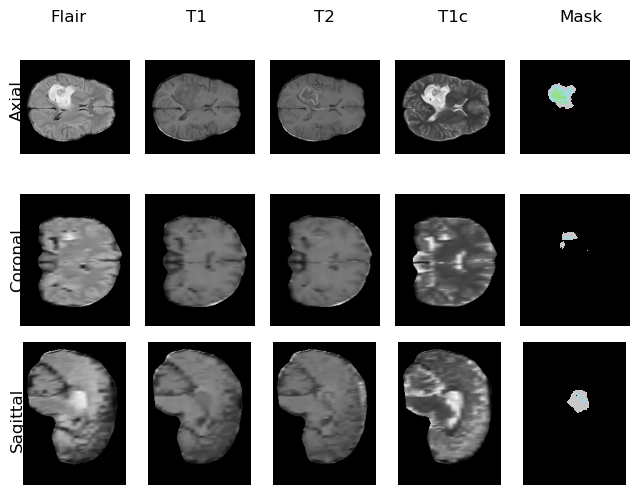

[[0. 0. 0. 0.]]
class 0: any=True, in frame 91=True
class 1: any=False, in frame 91=False
class 2: any=True, in frame 91=True
class 3: any=True, in frame 91=True


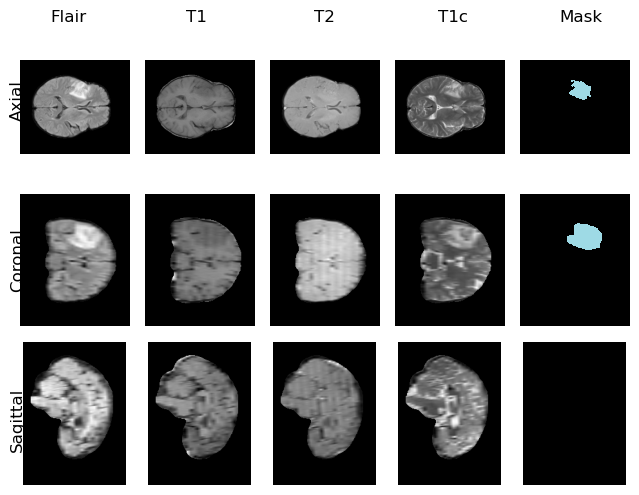

[[ 34. 107.  50. 118.]]
class 0: any=True, in frame 100=True
class 1: any=True, in frame 100=True
class 2: any=True, in frame 100=True
class 3: any=True, in frame 100=True


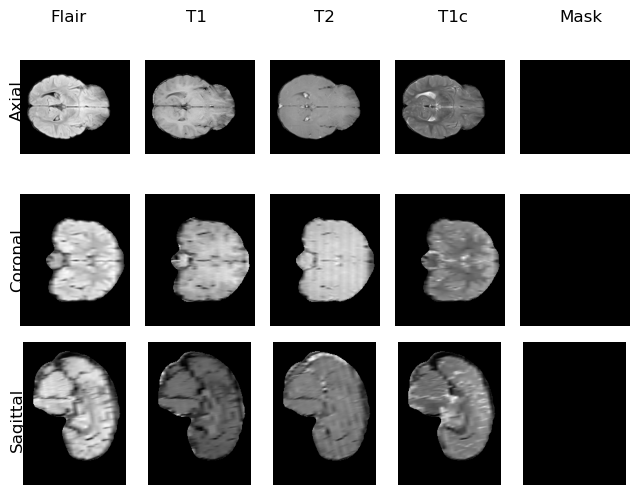

[[63. 52. 92. 80.]]
class 0: any=True, in frame 116=True
class 1: any=True, in frame 116=True
class 2: any=True, in frame 116=True
class 3: any=True, in frame 116=True


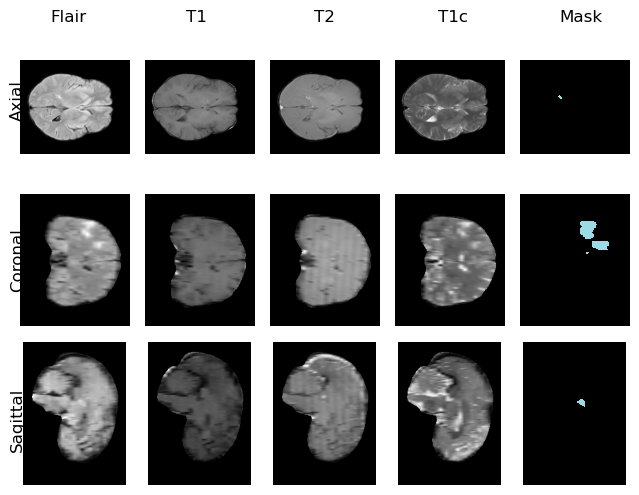

[[116.  91. 119.  99.]]
class 0: any=True, in frame 94=True
class 1: any=True, in frame 94=True
class 2: any=True, in frame 94=True
class 3: any=True, in frame 94=True


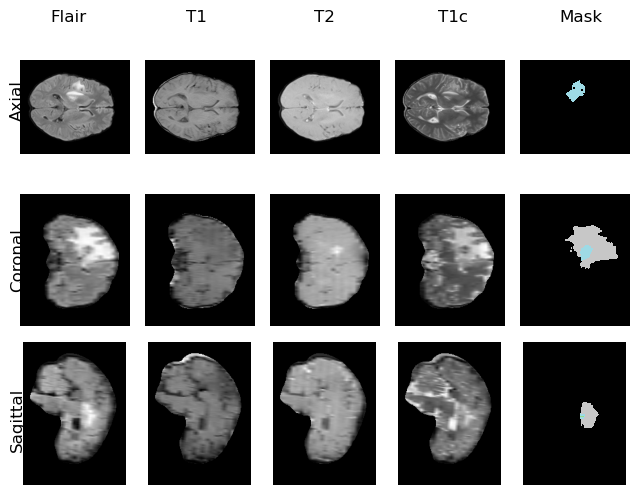

[[0. 0. 0. 0.]]
class 0: any=True, in frame 46=True
class 1: any=False, in frame 46=False
class 2: any=True, in frame 46=True
class 3: any=True, in frame 46=True


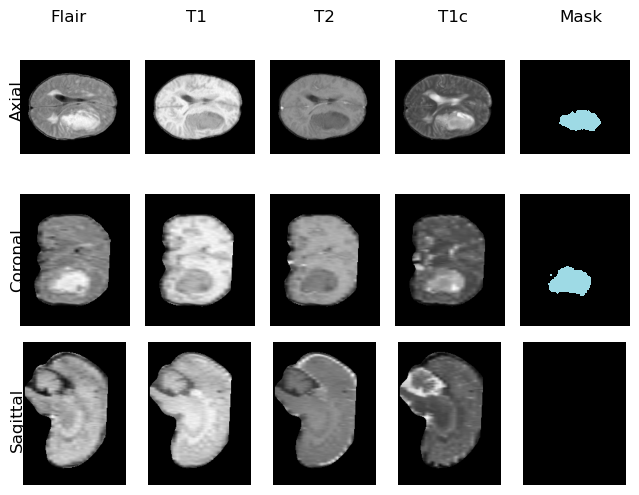

[[116. 125. 116. 126.]]
class 0: any=True, in frame 52=True
class 1: any=True, in frame 52=True
class 2: any=True, in frame 52=True
class 3: any=True, in frame 52=True


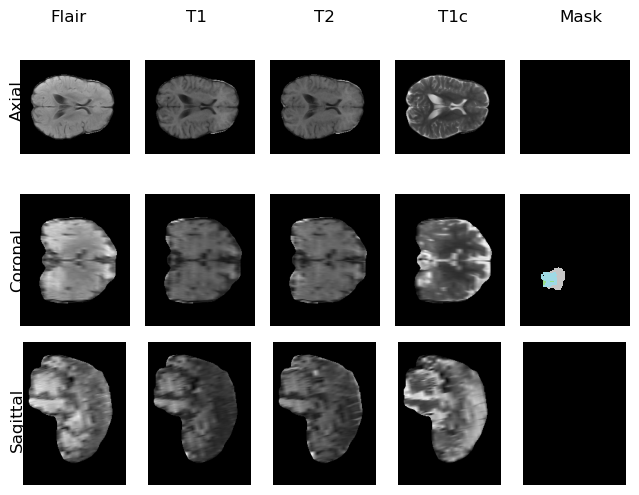

[[ 88.  88. 145. 122.]]
class 0: any=True, in frame 105=True
class 1: any=True, in frame 105=True
class 2: any=True, in frame 105=True
class 3: any=True, in frame 105=True


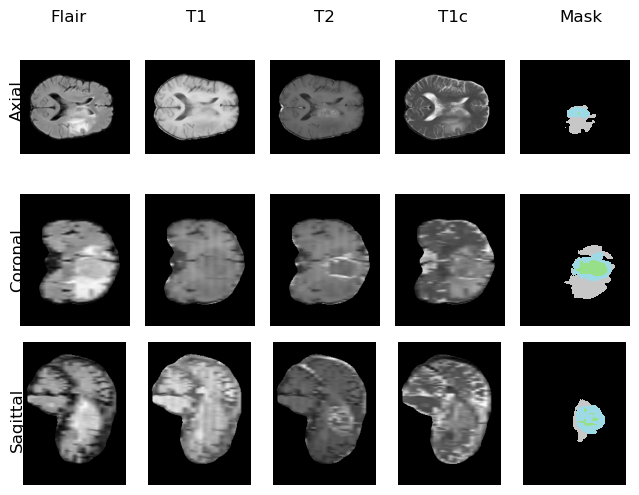

In [7]:
Brats_image_path = '/scratch-second/Preprocess_BraTS2023_SSA_Training/images_UNN'
Brats_label_path = '/scratch-second/Preprocess_BraTS2023_SSA_Training/labels_UNN'
GLI_FT_rows = random.sample(os.listdir(Brats_image_path), 10)
GLI_FT_dataset = MRIDataset(Brats_image_path, Brats_label_path, GLI_FT_rows)
visualize_brats(GLI_FT_dataset, Brats_label_path, 'GT Vs MedSAM2-BraTS-GLI', Brats_image_path)